In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [2]:
print("TensorFlow version:", tf.__version__)
print("Numpy version:", np.__version__)

TensorFlow version: 2.21.0
Numpy version: 2.4.3


In [3]:
IMAGE_PATH = r"C:/Users/Hp/OneDrive/Desktop/thesis part 2/dataset/train_images"
MASK_PATH = r"C:/Users/Hp/OneDrive/Desktop/thesis part 2/dataset/train_masks"

IMG_SIZE = 256

In [4]:
images = []
masks = []

image_names = sorted(os.listdir(IMAGE_PATH))

for name in image_names:

    image = cv2.imread(os.path.join(IMAGE_PATH, name))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(
        os.path.join(MASK_PATH, name),
        cv2.IMREAD_GRAYSCALE
    )

    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
    mask = cv2.resize(
        mask,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_NEAREST
    )

    image = image.astype(np.float32) / 255.0

    mask = (mask > 127).astype(np.float32)

    mask = np.expand_dims(mask, axis=-1)

    images.append(image)
    masks.append(mask)

In [5]:
images = np.array(images, dtype=np.float32)
masks = np.array(masks, dtype=np.float32)

print(images.shape)
print(masks.shape)

print(images.min(), images.max())
print(masks.min(), masks.max())

print(np.unique(masks))

(2208, 256, 256, 3)
(2208, 256, 256, 1)
0.0 1.0
0.0 1.0
[0. 1.]


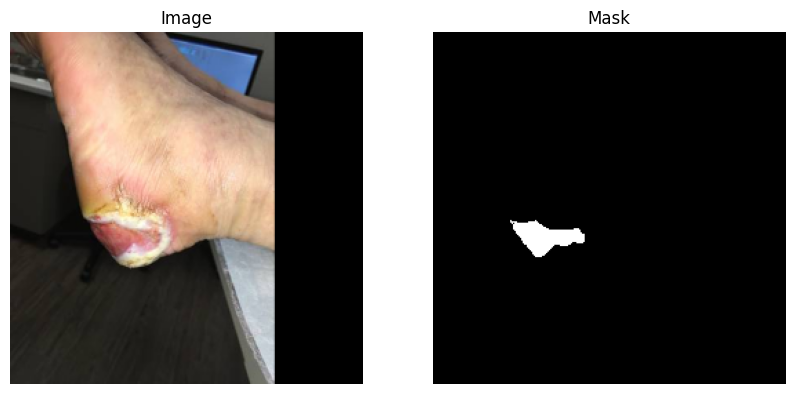

In [6]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(images[0])
plt.title("Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(masks[0].squeeze(), cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(
    images,
    masks,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [8]:
print("Training Images :", X_train.shape)
print("Training Masks :", Y_train.shape)

print("Testing Images :", X_test.shape)
print("Testing Masks :", Y_test.shape)

print(np.unique(Y_train))

Training Images : (1766, 256, 256, 3)
Training Masks : (1766, 256, 256, 1)
Testing Images : (442, 256, 256, 3)
Testing Masks : (442, 256, 256, 1)
[0. 1.]


In [9]:
# part 2 Training

In [10]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Conv2DTranspose, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [11]:
inputs = Input((256,256,3))

# Encoder
c1 = Conv2D(16,3,activation='relu',padding='same')(inputs)
c1 = Conv2D(16,3,activation='relu',padding='same')(c1)
p1 = MaxPooling2D((2,2))(c1)

c2 = Conv2D(32,3,activation='relu',padding='same')(p1)
c2 = Conv2D(32,3,activation='relu',padding='same')(c2)
p2 = MaxPooling2D((2,2))(c2)

c3 = Conv2D(64,3,activation='relu',padding='same')(p2)
c3 = Conv2D(64,3,activation='relu',padding='same')(c3)
p3 = MaxPooling2D((2,2))(c3)

c4 = Conv2D(128,3,activation='relu',padding='same')(p3)
c4 = Conv2D(128,3,activation='relu',padding='same')(c4)
p4 = MaxPooling2D((2,2))(c4)

# Bottleneck
c5 = Conv2D(256,3,activation='relu',padding='same')(p4)
c5 = Conv2D(256,3,activation='relu',padding='same')(c5)

# Decoder
u6 = Conv2DTranspose(128,2,strides=2,padding='same')(c5)
u6 = concatenate([u6,c4])
c6 = Conv2D(128,3,activation='relu',padding='same')(u6)
c6 = Conv2D(128,3,activation='relu',padding='same')(c6)

u7 = Conv2DTranspose(64,2,strides=2,padding='same')(c6)
u7 = concatenate([u7,c3])
c7 = Conv2D(64,3,activation='relu',padding='same')(u7)
c7 = Conv2D(64,3,activation='relu',padding='same')(c7)

u8 = Conv2DTranspose(32,2,strides=2,padding='same')(c7)
u8 = concatenate([u8,c2])
c8 = Conv2D(32,3,activation='relu',padding='same')(u8)
c8 = Conv2D(32,3,activation='relu',padding='same')(c8)

u9 = Conv2DTranspose(16,2,strides=2,padding='same')(c8)
u9 = concatenate([u9,c1])
c9 = Conv2D(16,3,activation='relu',padding='same')(u9)
c9 = Conv2D(16,3,activation='relu',padding='same')(c9)

outputs = Conv2D(1,1,activation='sigmoid')(c9)

model = Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_3[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │    590,080 │ conv2d_8[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │    131,200 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose

 Total params: 1,941,105 (7.40 MB)

 Trainable params: 1,941,105 (7.40 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [13]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    ModelCheckpoint(
        "best_unet_model.keras",
        monitor='val_loss',
        save_best_only=True
    )
]

In [15]:
history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_test, Y_test),
    epochs=20,
    batch_size=1,
    callbacks=callbacks
)

Epoch 1/20
1766/1766 ━━━━━━━━━━━━━━━━━━━━ 226s 128ms/step - accuracy: 0.9557 - loss: 0.1182 - val_accuracy: 0.9536 - val_loss: 0.1196
Epoch 2/20
1766/1766 ━━━━━━━━━━━━━━━━━━━━ 211s 119ms/step - accuracy: 0.9610 - loss: 0.1082 - val_accuracy: 0.9544 - val_loss: 0.1197
Epoch 3/20
1766/1766 ━━━━━━━━━━━━━━━━━━━━ 214s 121ms/step - accuracy: 0.9650 - loss: 0.0966 - val_accuracy: 0.9696 - val_loss: 0.0874
Epoch 4/20
1766/1766 ━━━━━━━━━━━━━━━━━━━━ 209s 118ms/step - accuracy: 0.9678 - loss: 0.0860 - val_accuracy: 0.9685 - val_loss: 0.0982
Epoch 5/20
1766/1766 ━━━━━━━━━━━━━━━━━━━━ 214s 121ms/step - accuracy: 0.9709 - loss: 0.0772 - val_accuracy: 0.9732 - val_loss: 0.0737
Epoch 6/20
1766/1766 ━━━━━━━━━━━━━━━━━━━━ 216s 122ms/step - accuracy: 0.9727 - loss: 0.0738 - val_accuracy: 0.9755 - val_loss: 0.0724
Epoch 7/20
1766/1766 ━━━━━━━━━━━━━━━━━━━━ 216s 122ms/step - accuracy: 0.9744 - loss: 0.0688 - val_accuracy: 0.9740 - val_loss: 0.0722
Epoch 8/20
1766/1766 ━━━━━━━━━━━━━━━━━━━━ 301s 171ms/step - ac

In [16]:
model.save("wound_segmentation_model2.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


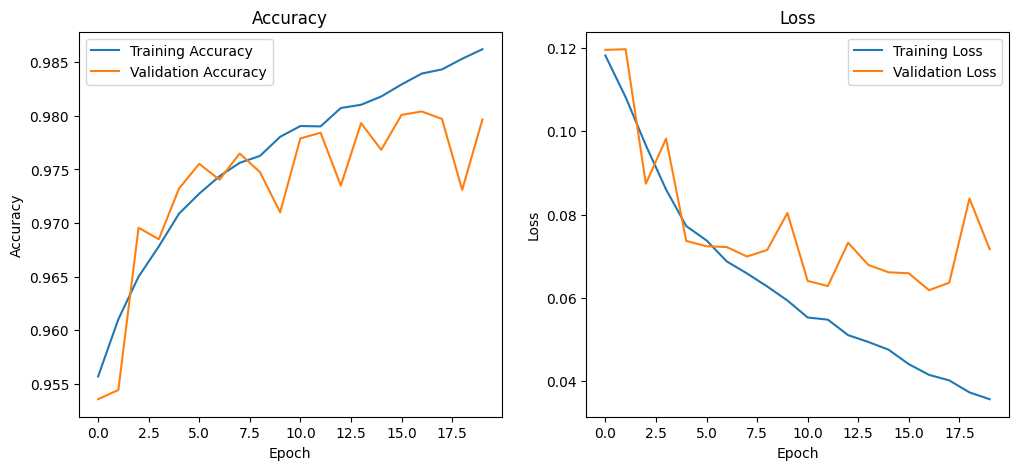

In [17]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [18]:
loss, accuracy = model.evaluate(X_test, Y_test)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 649ms/step - accuracy: 0.9804 - loss: 0.0618
Test Loss : 0.06184549629688263
Test Accuracy : 0.9804132580757141


In [19]:
#result of test loss and accuracy

In [20]:
predictions = model.predict(X_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 594ms/step


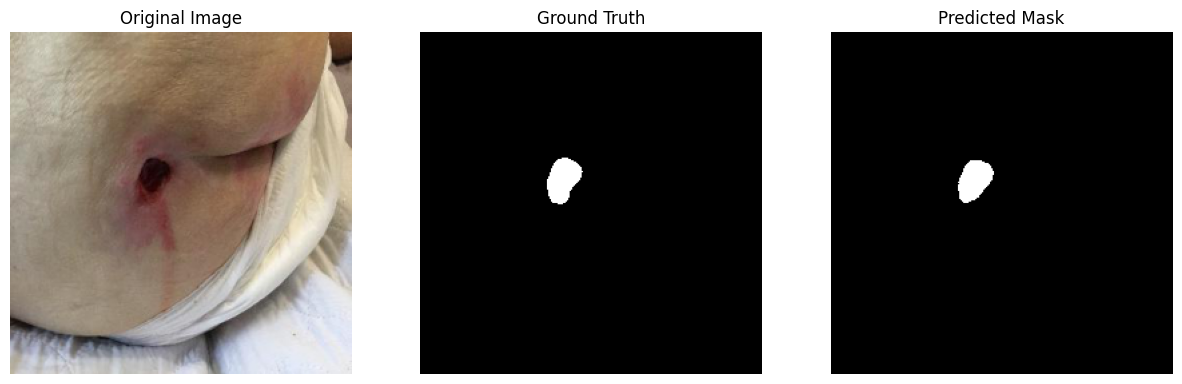

In [21]:
index = 0

pred_mask = (predictions[index] > 0.5).astype(np.uint8)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(X_test[index])
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(Y_test[index].squeeze(), cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred_mask.squeeze(), cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

In [22]:
def dice_score(y_true, y_pred):

    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    intersection = np.sum(y_true * y_pred)

    return (2. * intersection + 1e-7) / (
        np.sum(y_true) + np.sum(y_pred) + 1e-7
    )

In [23]:
def iou_score(y_true, y_pred):

    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    intersection = np.sum(y_true * y_pred)

    union = np.sum(y_true) + np.sum(y_pred) - intersection

    return (intersection + 1e-7) / (union + 1e-7)

In [24]:
pred_binary = (predictions > 0.5).astype(np.float32)

dice = dice_score(Y_test, pred_binary)
iou = iou_score(Y_test, pred_binary)

print("Dice Score :", dice)
print("IoU Score :", iou)

Dice Score : 0.774636
IoU Score : 0.63216805


In [25]:
model.save("wound_segmentation_final2.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


In [1]:
from tensorflow.keras.models import load_model

model = load_model("wound_segmentation_final2.keras")

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r"C:\Users\Hp\OneDrive\Desktop\thesis part 2\dataset\test_images\fusc_0909.png"

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

original = image.copy()

image = cv2.resize(image, (256,256))
image = image.astype(np.float32) / 255.0

img_input = np.expand_dims(image, axis=0)

In [27]:
prediction = model.predict(img_input)

prediction = (prediction > 0.1).astype(np.uint8)

mask = prediction[0].squeeze()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


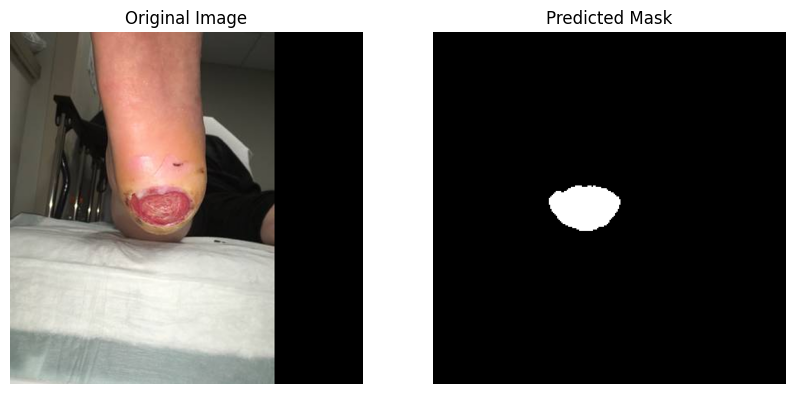

In [28]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

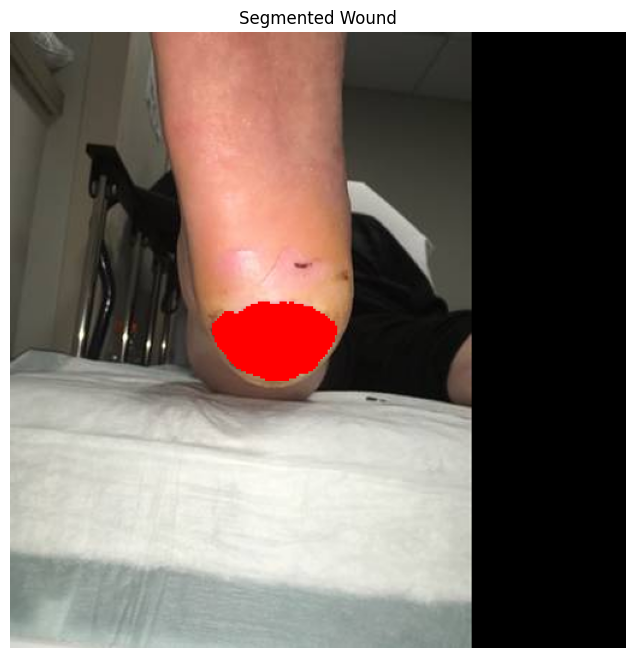

In [29]:
mask_resize = cv2.resize(mask, (original.shape[1], original.shape[0]))

overlay = original.copy()

overlay[mask_resize == 1] = [255,0,0]

plt.figure(figsize=(8,8))
plt.imshow(overlay)
plt.title("Segmented Wound")
plt.axis("off")
plt.show()